# CMT307 Applied Machine Learning — ASHRAE Great Energy Predictor III

**Cardiff University | Spring 2025/26 | Task 9: Energy Usage Prediction**

---

| | |
|---|---|
| **Name** | Zahra |
| **Role** | Person 4 — Data Merging & Integration Hub |
| **Notebook** | `Zahra_Data_Merging.ipynb` |

In [1]:
import pandas as pd
import os

DATA_DIR = '../data/ashrae-energy-prediction'

train        = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'), parse_dates=['timestamp'])
metadata     = pd.read_csv(os.path.join(DATA_DIR, 'building_metadata.csv'))
weather      = pd.read_csv(os.path.join(DATA_DIR, 'weather_train.csv'), parse_dates=['timestamp'])
test         = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'), parse_dates=['timestamp'])
weather_test = pd.read_csv(os.path.join(DATA_DIR, 'weather_test.csv'), parse_dates=['timestamp'])

print('train:       ', train.shape)
print('metadata:    ', metadata.shape)
print('weather:     ', weather.shape)
print('test:        ', test.shape)
print('weather_test:', weather_test.shape)

train:        (20216100, 4)
metadata:     (1449, 6)
weather:      (139773, 9)
test:         (41697600, 4)
weather_test: (277243, 9)


In [2]:
# Check all building_ids in train exist in metadata
missing_ids = set(train['building_id']) - set(metadata['building_id'])
print(f'building_ids in train not in metadata: {len(missing_ids)}')
print(f'unique buildings in train:    {train["building_id"].nunique()}')
print(f'unique buildings in metadata: {metadata["building_id"].nunique()}')

building_ids in train not in metadata: 0
unique buildings in train:    1449
unique buildings in metadata: 1449


In [3]:
# Merge train + metadata on building_id
merged_train = train.merge(metadata, on='building_id', how='left')
print('After train + metadata:', merged_train.shape)  # rows must stay at 20,216,100

# Merge + weather on site_id + timestamp
merged_train = merged_train.merge(weather, on=['site_id', 'timestamp'], how='left')
print('After + weather:       ', merged_train.shape)  # must still be 20,216,100

After train + metadata: (20216100, 9)
After + weather:        (20216100, 16)


In [4]:
# Null counts after merge
nulls = merged_train.isnull().sum()
print(nulls[nulls > 0])

year_built            12127645
floor_count           16709167
air_temperature          96658
cloud_coverage         8825365
dew_temperature         100140
precip_depth_1_hr      3749023
sea_level_pressure     1231669
wind_direction         1449048
wind_speed              143676
dtype: int64


In [5]:
# Repeat for test
merged_test = test.merge(metadata, on='building_id', how='left')
merged_test = merged_test.merge(weather_test, on=['site_id', 'timestamp'], how='left')
print('merged_test:', merged_test.shape)

nulls_test = merged_test.isnull().sum()
print(nulls_test[nulls_test > 0])

merged_test: (41697600, 16)
year_built            24598080
floor_count           34444320
air_temperature         221901
cloud_coverage        19542180
dew_temperature         260799
precip_depth_1_hr      7801563
sea_level_pressure     2516826
wind_direction         2978663
wind_speed              302089
dtype: int64


In [6]:
# Save merged files as CSV
os.makedirs('../data_processed', exist_ok=True)
merged_train.to_csv('../data_processed/merged_train.csv', index=False)
merged_test.to_csv('../data_processed/merged_test.csv', index=False)
print('Saved merged_train.csv and merged_test.csv to data_processed/')

Saved merged_train.csv and merged_test.csv to data_processed/


### Key Findings

- All 5 files loaded successfully: train (20,216,100 rows), metadata (1,449), weather_train (139,773), test (41,697,600), weather_test (277,243)
- All 1,449 building IDs in train are present in metadata — no orphan records
- Both merges preserved row count exactly (20,216,100 for train, 41,697,600 for test) — no row duplication or loss
- 16 columns in final merged tables (4 original + 5 metadata + 7 weather features)
- Columns with missing values after merge:
  - `year_built`: 60% missing — sparse in source metadata
  - `floor_count`: 83% missing — sparse in source metadata
  - `cloud_coverage`: 44% missing — weather station gaps
  - `precip_depth_1_hr`: 19% missing
  - `sea_level_pressure`: 6% missing
  - `wind_direction`: 7% missing
  - `air_temperature`, `dew_temperature`, `wind_speed`: <1% missing
- Missing weather values are due to gaps in the original weather station recordings, not a merge error
- Saved: `merged_train.csv` and `merged_test.csv` to `data_processed/`

---

## Sprint 2 — Data Merging, Preprocessing & Feature Engineering

In [2]:
import pandas as pd
import numpy as np
import os
import gc

PROCESSED_DIR = '../data_processed'
DATA_DIR      = '../data/ashrae-energy-prediction'
OUTPUTS_DIR   = '../outputs'

# Load Zahra's Sprint 1 merged files as the pipeline base
print("Loading Sprint 1 merged files...")
df_train = pd.read_csv(
    os.path.join(PROCESSED_DIR, 'merged_train.csv'),
    dtype={'building_id': 'int16', 'meter': 'int8', 'site_id': 'int8'},
    parse_dates=['timestamp']
)
df_test = pd.read_csv(
    os.path.join(PROCESSED_DIR, 'merged_test.csv'),
    dtype={'building_id': 'int16', 'meter': 'int8', 'site_id': 'int8'},
    parse_dates=['timestamp']
)

print(f"df_train : {df_train.shape}")
print(f"df_test  : {df_test.shape}")
print(f"Columns  : {list(df_train.columns)}")

Loading Sprint 1 merged files...
df_train : (20216100, 24)
df_test  : (41697600, 23)
Columns  : ['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id', 'primary_use', 'square_feet', 'year_built', 'floor_count', 'air_temperature', 'cloud_coverage', 'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed', 'hour', 'day_of_week', 'month', 'day_of_year', 'season', 'is_weekend', 'is_business_hours', 'log_meter_reading']


In [3]:
# ── Card 8 (Wahid): Fix Missing Building Features + Encode Categories ─────────

# A: Flag missing floor_count BEFORE imputing (used as a model feature itself)
df_train['missing_floor_count_flag'] = df_train['floor_count'].isnull().astype(np.int8)
df_test['missing_floor_count_flag']  = df_test['floor_count'].isnull().astype(np.int8)

# B: Impute floor_count — group median cascade (primary_use + site_id + sqft_bin → fallbacks)
for df in [df_train, df_test]:
    df['sqft_bin'] = pd.qcut(df['square_feet'], q=5, duplicates='drop')
    df['floor_count'] = df['floor_count'].fillna(
        df.groupby(['primary_use', 'site_id', 'sqft_bin'], observed=True)['floor_count'].transform('median'))
    df['floor_count'] = df['floor_count'].fillna(
        df.groupby(['primary_use', 'sqft_bin'], observed=True)['floor_count'].transform('median'))
    df['floor_count'] = df['floor_count'].fillna(
        df.groupby('sqft_bin', observed=True)['floor_count'].transform('median'))
    df['floor_count'] = df['floor_count'].fillna(df['floor_count'].median())
    df['floor_count'] = df['floor_count'].round().astype(np.int8)
    df.drop(columns=['sqft_bin'], inplace=True)

# C: Impute year_built — group median cascade
for df in [df_train, df_test]:
    df['year_built'] = df['year_built'].fillna(
        df.groupby(['primary_use', 'site_id'], observed=True)['year_built'].transform('median'))
    df['year_built'] = df['year_built'].fillna(
        df.groupby('primary_use', observed=True)['year_built'].transform('median'))
    df['year_built'] = df['year_built'].fillna(df['year_built'].median())

# D: Derived features
for df in [df_train, df_test]:
    df['building_age']    = (2016 - df['year_built']).astype(np.int16)
    df['log_square_feet'] = np.log1p(df['square_feet']).astype(np.float32)

# E: One-hot encode primary_use (fit categories on train, apply same columns to test)
all_uses = sorted(df_train['primary_use'].unique())
for use in all_uses:
    col = f'use_{use}'
    df_train[col] = (df_train['primary_use'] == use).astype(np.int8)
    df_test[col]  = (df_test['primary_use']  == use).astype(np.int8)

# F: Drop raw columns replaced by engineered ones
for df in [df_train, df_test]:
    df.drop(columns=[c for c in ['primary_use', 'square_feet', 'year_built'] if c in df.columns], inplace=True)

gc.collect()
use_cols = [c for c in df_train.columns if c.startswith('use_')]
print(f"Building features applied | {len(use_cols)} use_* columns")
print(f"Null check — floor_count: {df_train['floor_count'].isnull().sum()} | building_age: {df_train['building_age'].isnull().sum()}")

Building features applied | 16 use_* columns
Null check — floor_count: 0 | building_age: 0


In [4]:
# ── Card 9 (Tanisha): Impute Weather + Engineer Weather Features ──────────────
# Load raw weather files and apply Tanisha's preprocessing at the station level
# (1 row per site+timestamp), then re-merge into the main dataframes

weather_train_raw = pd.read_csv(
    os.path.join(DATA_DIR, 'weather_train.csv'), parse_dates=['timestamp']
).sort_values(['site_id', 'timestamp']).reset_index(drop=True)

weather_test_raw = pd.read_csv(
    os.path.join(DATA_DIR, 'weather_test.csv'), parse_dates=['timestamp']
).sort_values(['site_id', 'timestamp']).reset_index(drop=True)

def preprocess_weather(df):
    df = df.copy()
    for col in ['air_temperature', 'dew_temperature']:
        df[col] = df.groupby('site_id')[col].transform(
            lambda x: x.interpolate(method='linear', limit_direction='both'))
    df['cloud_coverage'] = df.groupby('site_id')['cloud_coverage'].transform(
        lambda x: x.ffill().bfill())
    df['cloud_coverage'] = df.groupby('site_id')['cloud_coverage'].transform(
        lambda x: x.fillna(x.median()))
    df['cloud_coverage'] = df['cloud_coverage'].fillna(df['cloud_coverage'].median())
    df['precip_was_missing'] = df['precip_depth_1_hr'].isna().astype(np.int8)
    df['precip_depth_1_hr']  = df['precip_depth_1_hr'].fillna(0)
    for col in ['sea_level_pressure', 'wind_direction']:
        rolled = df.groupby('site_id')[col].transform(
            lambda x: x.rolling(24, min_periods=1).median())
        df[col] = df[col].fillna(rolled)
        df[col] = df.groupby('site_id')[col].transform(lambda x: x.fillna(x.median()))
    df['relative_humidity'] = (100 * (
        np.exp((17.625 * df['dew_temperature']) / (243.04 + df['dew_temperature'])) /
        np.exp((17.625 * df['air_temperature']) / (243.04 + df['air_temperature']))
    )).clip(0, 100)
    df['temp_diff_from_comfort'] = (df['air_temperature'] - 21).abs()
    return df

weather_train_proc = preprocess_weather(weather_train_raw)
weather_test_proc  = preprocess_weather(weather_test_raw)

# Cast float64 -> float32 before merge to halve memory usage
# (df_test has 41.7M rows -- float64 weather cols need 3.1 GB, float32 needs ~1.5 GB)
for wdf in [weather_train_proc, weather_test_proc]:
    for col in wdf.select_dtypes(include='float64').columns:
        wdf[col] = wdf[col].astype(np.float32)

gc.collect()

# Drop old raw weather columns and re-merge with processed ones
weather_raw_cols = ['air_temperature', 'cloud_coverage', 'dew_temperature',
                    'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed']
df_train.drop(columns=[c for c in weather_raw_cols if c in df_train.columns], inplace=True)
df_test.drop( columns=[c for c in weather_raw_cols if c in df_test.columns],  inplace=True)

df_train = df_train.merge(weather_train_proc, on=['site_id', 'timestamp'], how='left')
df_test  = df_test.merge( weather_test_proc,  on=['site_id', 'timestamp'], how='left')

del weather_train_proc, weather_test_proc, weather_train_raw, weather_test_raw
gc.collect()

# Final fallback: ~0.4% of rows have timestamps entirely absent from the weather files
weather_feature_cols = [
    'air_temperature', 'cloud_coverage', 'dew_temperature',
    'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed',
    'precip_was_missing', 'relative_humidity', 'temp_diff_from_comfort'
]
for df in [df_train, df_test]:
    for col in weather_feature_cols:
        if col in df.columns and df[col].isnull().any():
            df[col] = df.groupby('site_id')[col].transform(lambda x: x.ffill().bfill())
            df[col] = df.groupby('site_id')[col].transform(lambda x: x.fillna(x.median()))
            df[col] = df[col].fillna(df[col].median())

gc.collect()
remaining = {c: int(df_train[c].isnull().sum()) for c in weather_feature_cols if c in df_train.columns}
remaining = {k: v for k, v in remaining.items() if v > 0}
print(f"Weather features applied | df_train: {df_train.shape}")
print(f"Remaining nulls after fallback: {remaining if remaining else 'None -- all clean'}")

Weather features applied | df_train: (20216100, 43)
Remaining nulls after fallback: None -- all clean


In [5]:
# ── Card 7 (Shriya): Time Features + Target Transformation ───────────────────
def get_season(month):
    if month in [12, 1, 2]:  return 0  # winter
    elif month in [3, 4, 5]: return 1  # spring
    elif month in [6, 7, 8]: return 2  # summer
    else:                    return 3  # autumn

for df in [df_train, df_test]:
    df['hour']              = df['timestamp'].dt.hour.astype(np.int8)
    df['day_of_week']       = df['timestamp'].dt.dayofweek.astype(np.int8)
    df['month']             = df['timestamp'].dt.month.astype(np.int8)
    df['day_of_year']       = df['timestamp'].dt.dayofyear.astype(np.int16)
    df['season']            = df['month'].map(get_season).astype(np.int8)
    df['is_weekend']        = (df['day_of_week'] >= 5).astype(np.int8)
    df['is_business_hours'] = (
        (df['hour'] >= 8) & (df['hour'] <= 18) & (df['day_of_week'] < 5)
    ).astype(np.int8)

df_train['log_meter_reading'] = np.log1p(df_train['meter_reading'])
print("Time features applied:", ['hour','day_of_week','month','day_of_year','season','is_weekend','is_business_hours','log_meter_reading'])

# ── Card 6 (Ayan): Anomaly Cleaning ──────────────────────────────────────────
rows_start = len(df_train)

# Decision 1: Remove Site 0 electricity rows before 2016-05-20
# Ayan found 93.75% of these readings are exactly zero — a known calibration gap
site0_mask = (
    (df_train['site_id'] == 0) &
    (df_train['meter']   == 0) &
    (df_train['timestamp'] < '2016-05-20')
)
df_train = df_train[~site0_mask].copy()
gc.collect()
print(f"\nRemoved {rows_start - len(df_train):,} rows — Site 0 electricity calibration gap (before 2016-05-20)")

# Decision 2: Remove building/meter pairs flagged for zero streaks > 168 hours
anomaly_df = pd.read_csv(
    os.path.join(OUTPUTS_DIR, 'anomaly_report.csv'),
    usecols=['anomaly_type', 'building_id', 'meter']
)
zero_streak_pairs = (
    anomaly_df[anomaly_df['anomaly_type'] == 'zero_streak'][['building_id', 'meter']]
    .drop_duplicates()
)
print(f"Building/meter pairs with zero streaks >168 h: {len(zero_streak_pairs)}")

train_midx  = pd.MultiIndex.from_arrays([df_train['building_id'], df_train['meter']])
streak_midx = pd.MultiIndex.from_frame(zero_streak_pairs)
rows_before = len(df_train)
df_train = df_train[~train_midx.isin(streak_midx)].copy()
gc.collect()
print(f"Removed {rows_before - len(df_train):,} rows — zero streak building/meter pairs")
print(f"\nTotal removed: {rows_start - len(df_train):,} rows ({(rows_start - len(df_train))/rows_start*100:.2f}%)")
print(f"df_train after cleaning: {df_train.shape}")

Time features applied: ['hour', 'day_of_week', 'month', 'day_of_year', 'season', 'is_weekend', 'is_business_hours', 'log_meter_reading']

Removed 346,112 rows — Site 0 electricity calibration gap (before 2016-05-20)
Building/meter pairs with zero streaks >168 h: 313
Removed 2,380,183 rows — zero streak building/meter pairs

Total removed: 2,726,295 rows (13.49%)
df_train after cleaning: (17489805, 43)


In [6]:
# ── Final Null Check ─────────────────────────────────────────────────────────
skip_cols = {'timestamp', 'meter_reading', 'log_meter_reading', 'row_id'}
check_cols = [c for c in df_train.columns if c not in skip_cols]

nulls = df_train[check_cols].isnull().sum()
remaining = nulls[nulls > 0]
if len(remaining) == 0:
    print("No nulls in any feature column — pipeline is clean.")
else:
    print("WARNING — nulls remain:")
    print(remaining)

# ── Time-Based Train / Validation Split ──────────────────────────────────────
# Train: Jan–Oct 2016 | Val: Nov–Dec 2016
# Time-based split is essential — a random split would leak future timestamps into training
train_final = df_train[df_train['timestamp'] < '2016-11-01'].copy()
val_final   = df_train[df_train['timestamp'] >= '2016-11-01'].copy()

assert len(train_final) + len(val_final) == len(df_train), "Split lost rows!"

print(f"\ntrain_final : {train_final.shape}  {train_final['timestamp'].min().date()} → {train_final['timestamp'].max().date()}")
print(f"val_final   : {val_final.shape}  {val_final['timestamp'].min().date()} → {val_final['timestamp'].max().date()}")
print(f"Split       : Train {len(train_final)/len(df_train)*100:.1f}%  /  Val {len(val_final)/len(df_train)*100:.1f}%")

# ── Save ──────────────────────────────────────────────────────────────────────
os.makedirs(PROCESSED_DIR, exist_ok=True)
train_final.to_csv(os.path.join(PROCESSED_DIR, 'final_train.csv'), index=False)
val_final.to_csv(  os.path.join(PROCESSED_DIR, 'final_val.csv'),   index=False)
df_test.to_csv(    os.path.join(PROCESSED_DIR, 'final_test.csv'),  index=False)

print(f"\nSaved to {PROCESSED_DIR}/")
print(f"  final_train.csv — {train_final.shape}")
print(f"  final_val.csv   — {val_final.shape}")
print(f"  final_test.csv  — {df_test.shape}")

No nulls in any feature column — pipeline is clean.

train_final : (14529655, 43)  2016-01-01 → 2016-10-31
val_final   : (2960150, 43)  2016-11-01 → 2016-12-31
Split       : Train 83.1%  /  Val 16.9%

Saved to ../data_processed/
  final_train.csv — (14529655, 43)
  final_val.csv   — (2960150, 43)
  final_test.csv  — (41697600, 42)


### Sprint 2 Key Decisions

| Step | What Was Applied | Source |
|---|---|---|
| Building imputation | `floor_count`: group median cascade (primary_use + site_id + sqft_bin); `year_built`: same cascade | Wahid (Card 8) |
| Building features | `building_age` = 2016 − year_built; `log_square_feet` = log1p(square_feet); one-hot `primary_use` → 16 `use_*` columns | Wahid (Card 8) |
| Weather imputation | `air_temperature`, `dew_temperature`: linear interpolation per site; `cloud_coverage`: ffill/bfill + median; `precip`: fill 0 + flag; `sea_level_pressure`, `wind_direction`: 24h rolling median | Tanisha (Card 9) |
| Weather features | `relative_humidity`, `temp_diff_from_comfort`, `precip_was_missing` | Tanisha (Card 9) |
| Time features | `hour`, `day_of_week`, `month`, `day_of_year`, `season`, `is_weekend`, `is_business_hours`, `log_meter_reading` | Shriya (Card 7) |
| Anomaly removal | Site 0 electricity before 2016-05-20 removed; building/meter pairs with zero streaks >168 h removed | Ayan (Card 6) |
| Train/val split | Jan–Oct 2016 = train (~83%), Nov–Dec 2016 = val (~17%) — time-based to prevent leakage | Card 10 |

---
## Sprint 3 — Ensemble
### Objective

Combine all five Sprint 3 models (LightGBM, XGBoost, CatBoost, Random Forest, Linear Regression) using two ensemble strategies — **Hard Voting** and **Soft Voting** — and compare them against individual model baselines.

### Ensemble Strategies

| Strategy | Definition (regression) | Implementation |
|---|---|---|
| **Hard Voting** | Equal weight to every selected model — unweighted average (each model has one vote regardless of quality) | `mean([pred_lgb, pred_xgb, pred_cat, pred_rf, pred_lr])` |
| **Soft Voting** | Weight each model by its validation performance — better models get a proportionally larger vote | `weighted_mean` with `w ∝ 1/RMSLE²` |

> **Note:** In classification, hard voting picks the majority class and soft voting averages probabilities. The regression analogue is equal-weight average (hard) vs performance-weighted average (soft).

### Sprint 3 Models Available

| Team Member | Model | Saved File | Val RMSLE |
|---|---|---|---|
| Wahid | XGBoost | `xgb_model.pkl` | **0.5207** |
| Shivalika | LightGBM (n=500, lr=0.05) | `lightgbm_model.pkl` | 0.5231 |
| Wahid | CatBoost | `catboost_model.pkl` | 0.5234 |
| Ayan | Random Forest (depth=20, n=400) | `rf_model_depth20.pkl` | 0.5267 |
| Wahid | Linear Regression | `lr_model.pkl` | 1.5989 |
| Ayan | Random Forest fallback (depth=10, n=300) | `rf_model_depth10.pkl` | 0.5727 |
| Ayan | Baseline Median | — | 1.3254 |

The five ensemble candidates were trained on `final_train_with_features.csv` and evaluated on `final_val_with_features.csv`.  
All models predict in **log-scale** (trained on `log1p(meter_reading)`) → must apply `expm1()` to recover actual values.

---
## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import joblib
import os
import sys
import subprocess
import importlib.util
import warnings
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
warnings.filterwarnings('ignore')

# XGBoost/CatBoost classes must be importable before joblib can unpickle Wahid's saved models.
for package_name, module_name in [('xgboost', 'xgboost'), ('catboost', 'catboost')]:
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package_name, '-q'])
        importlib.invalidate_caches()

print('Libraries loaded.')
print('NumPy:', np.__version__, ' | Pandas:', pd.__version__)

Libraries loaded.
NumPy: 1.26.4  | Pandas: 2.1.4


---
## 2. Load Test Data

In [ ]:
test = pd.read_csv('../data_processed/final_test_with_features.csv')

print(f'Shape          : {test.shape}')
print(f'Columns ({len(test.columns)})   : {list(test.columns)}')
print(f'Date range     : {test["timestamp"].min()} → {test["timestamp"].max()}')
print(f'Null count     : {test.isnull().sum().sum()}')

# Ensure timestamp is string (don't need datetime for ensemble)
test['timestamp'] = test['timestamp'].astype(str)

Shape          : (2614072, 49)
Columns (49)   : ['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id', 'floor_count', 'hour', 'day_of_week', 'month', 'day_of_year', 'season', 'is_weekend', 'is_business_hours', 'log_meter_reading', 'missing_floor_count_flag', 'building_age', 'log_square_feet', 'use_Education', 'use_Entertainment/public assembly', 'use_Food sales and service', 'use_Healthcare', 'use_Lodging/residential', 'use_Manufacturing/industrial', 'use_Office', 'use_Other', 'use_Parking', 'use_Public services', 'use_Religious worship', 'use_Retail', 'use_Services', 'use_Technology/science', 'use_Utility', 'use_Warehouse/storage', 'air_temperature', 'cloud_coverage', 'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed', 'precip_was_missing', 'relative_humidity', 'temp_diff_from_comfort', 'lag_24h', 'lag_72h', 'lag_168h', 'rolling_mean_24h', 'rolling_std_24h', 'rolling_mean_168h']
Date range     : 2016-11-08 00:00:00 → 2016-12-31 23:0

---
## 3. Helper Functions

In [ ]:
DROP_COLS = ['meter_reading', 'log_meter_reading', 'timestamp', 'building_id']
BASELINE_RMSLE = 1.3254289914945556

y_val = test['meter_reading'].values

def rmsle(y_true, y_pred):
    """RMSLE — clip negatives before log to avoid NaN."""
    y_pred = np.maximum(y_pred, 0)
    y_true = np.maximum(y_true, 0)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

def get_model_feature_names(model):
    """Return feature names stored by sklearn, XGBoost, LightGBM, or CatBoost models."""
    for attr in ('feature_names_in_', 'feature_names_', 'feature_name_'):
        if hasattr(model, attr):
            names = getattr(model, attr)
            if callable(names):
                names = names()
            if names is not None:
                names = list(names)
                if names:
                    return names
    return None

def get_X(df, model):
    """Drop target/ID columns; reindex to the model's stored feature list when available."""
    X = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
    feature_names = get_model_feature_names(model)
    if feature_names is not None:
        X = X.reindex(columns=feature_names, fill_value=0)
    return X.fillna(0)

METER_NAMES = {0: 'Electricity', 1: 'Chilled Water', 2: 'Steam', 3: 'Hot Water'}

print('Helpers ready.  y_val shape:', y_val.shape)

Helpers ready.  y_val shape: (2614072,)


---
## 4. Load Saved Models


In [ ]:
rf_pkl = '../outputs/rf_model_depth20.pkl'
if not os.path.exists(rf_pkl):
    rf_pkl = '../outputs/rf_model_depth10.pkl'
    print('rf_model_depth20.pkl not found — falling back to rf_model_depth10.pkl (depth=10).')
rf_name = 'Random Forest (depth=20)' if os.path.basename(rf_pkl) == 'rf_model_depth20.pkl' else 'Random Forest (depth=10 fallback)'

model_specs = [
    {'key': 'lgb', 'name': 'LightGBM', 'short': 'LGB', 'path': '../outputs/lightgbm_model.pkl', 'family': 'tree'},
    {'key': 'xgb', 'name': 'XGBoost', 'short': 'XGB', 'path': '../outputs/xgb_model.pkl', 'family': 'tree'},
    {'key': 'cat', 'name': 'CatBoost', 'short': 'Cat', 'path': '../outputs/catboost_model.pkl', 'family': 'tree'},
    {'key': 'rf', 'name': rf_name, 'short': 'RF', 'path': rf_pkl, 'family': 'tree'},
    {'key': 'lr', 'name': 'Linear Regression', 'short': 'LR', 'path': '../outputs/lr_model.pkl', 'family': 'linear'},
]

models = {}
for spec in model_specs:
    if not os.path.exists(spec['path']):
        raise FileNotFoundError(f"Missing saved model for {spec['name']}: {spec['path']}")
    spec['model'] = joblib.load(spec['path'])
    models[spec['key']] = spec['model']
    print(f"{spec['name']} loaded from: {os.path.basename(spec['path'])}")

model_lookup = {spec['key']: spec for spec in model_specs}
lgb_model = models['lgb']
xgb_model = models['xgb']
cat_model = models['cat']
rf_model = models['rf']
lr_model = models['lr']

---
## 5. Generate Individual Predictions

All five ensemble models were trained on `log1p(meter_reading)` targets → raw output is log-scale → apply `expm1()` to convert back to actual meter readings.

In [ ]:
predictions = {}

for spec in model_specs:
    X = get_X(test, spec['model'])
    pred_log = spec['model'].predict(X)
    pred = np.expm1(np.maximum(pred_log, 0))
    predictions[spec['key']] = pred
    spec['n_features'] = X.shape[1]
    print(f"{spec['name']:<28}: {X.shape[1]} features, predictions range [{pred.min():.2f}, {pred.max():.2f}]")

pred_lgb = predictions['lgb']
pred_xgb = predictions['xgb']
pred_cat = predictions['cat']
pred_rf = predictions['rf']
pred_lr = predictions['lr']

LightGBM                    : 46 features, predictions range [0.00, 84817.43]
XGBoost                     : 45 features, predictions range [0.00, 293406.94]
CatBoost                    : 45 features, predictions range [0.00, 695734.87]
Random Forest (depth=20)    : 45 features, predictions range [0.00, 465950.24]
Linear Regression           : 45 features, predictions range [0.00, 126109109.02]


---
## 6. Individual Model RMSLE

In [8]:
for spec in model_specs:
    spec['rmsle'] = rmsle(y_val, predictions[spec['key']])

rmsle_by_key = {spec['key']: spec['rmsle'] for spec in model_specs}
rmsle_lgb = rmsle_by_key['lgb']
rmsle_xgb = rmsle_by_key['xgb']
rmsle_cat = rmsle_by_key['cat']
rmsle_rf = rmsle_by_key['rf']
rmsle_lr = rmsle_by_key['lr']

single_model_scores = pd.DataFrame([
    {'Model': spec['name'], 'Overall RMSLE': spec['rmsle'], 'Features': spec['n_features']}
    for spec in model_specs
]).sort_values('Overall RMSLE').reset_index(drop=True)

print('=== Individual Model RMSLE ===')
display(single_model_scores)
print(f'Baseline Median  : {BASELINE_RMSLE:.4f}  (reference)')

=== Individual Model RMSLE ===


,Model,Overall RMSLE,Features
0,XGBoost,0.520705,45
1,LightGBM,0.523051,46
2,CatBoost,0.523432,45
3,Random Forest (depth=20),0.526711,45
4,Linear Regression,1.598901,45


Baseline Median  : 1.3254  (reference)


---
## 7. Hard Voting Ensemble

**Hard Voting** gives every model an **equal vote** — each model's prediction contributes with weight 1/N regardless of individual performance.  
Equivalent to sklearn's `VotingRegressor` with no weights argument.

$$\hat{y}_{\text{hard}} = \frac{1}{N} \sum_{i=1}^{N} \hat{y}_i$$

We test four hard-voting combinations:
- **HV-2**: best two individual models by validation RMSLE
- **HV-4-tree**: all four tree/boosting models (LightGBM + XGBoost + CatBoost + Random Forest)
- **HV-5-all**: all five models, including Linear Regression
- **HV-median-5**: median across all five models, robust to one outlier model

In [9]:
def model_label(keys):
    return ' + '.join(model_lookup[key]['short'] for key in keys)

def average_prediction(keys):
    return np.mean(np.stack([predictions[key] for key in keys], axis=1), axis=1)

ranked_keys = [spec['key'] for spec in sorted(model_specs, key=lambda s: s['rmsle'])]
best2_keys = ranked_keys[:2]
tree_keys = [spec['key'] for spec in model_specs if spec['family'] == 'tree']
all_keys = [spec['key'] for spec in model_specs]

hard_ensemble_defs = {
    f"HV-2 best ({model_label(best2_keys)})": average_prediction(best2_keys),
    f"HV-4 tree ({model_label(tree_keys)})": average_prediction(tree_keys),
    f"HV-5 all ({model_label(all_keys)})": average_prediction(all_keys),
    f"HV-median-5 ({model_label(all_keys)})": np.median(np.stack([predictions[key] for key in all_keys], axis=1), axis=1),
}

hard_results = {}
for name, pred in hard_ensemble_defs.items():
    hard_results[name] = {'pred': pred, 'rmsle': rmsle(y_val, pred)}

hard_summary = pd.DataFrame([
    {'Model': name, 'Overall RMSLE': result['rmsle']}
    for name, result in hard_results.items()
]).sort_values('Overall RMSLE').reset_index(drop=True)

print('=== Hard Voting RMSLE ===')
display(hard_summary)
print(f'Linear Regression RMSLE is {rmsle_lr:.4f}, so equal-weight all-model voting may be pulled away from the stronger tree models.')

=== Hard Voting RMSLE ===


,Model,Overall RMSLE
0,HV-4 tree (LGB + XGB + Cat + RF),0.517427
1,HV-2 best (XGB + LGB),0.518177
2,HV-median-5 (LGB + XGB + Cat + RF + LR),0.519078
3,HV-5 all (LGB + XGB + Cat + RF + LR),0.813998


Linear Regression RMSLE is 1.5989, so equal-weight all-model voting may be pulled away from the stronger tree models.


---
## 8. Soft Voting Ensemble

**Soft Voting** weights each model proportionally to its validation performance.  
Better models are trusted more; poor models are automatically down-weighted.

$$w_i = \frac{1}{\text{RMSLE}_i^2}, \qquad \hat{y}_{\text{soft}} = \frac{\sum_i w_i \hat{y}_i}{\sum_i w_i}$$

Using 1/RMSLE² (inverse-squared) amplifies the advantage of the best model more than plain 1/RMSLE.

We test three soft-voting combinations:
- **SV-2**: best two individual models, performance-weighted
- **SV-4-tree**: all four tree/boosting models, performance-weighted
- **SV-5-all**: all five models, performance-weighted

In [10]:
# compute weights = 1 / RMSLE²
weights = {spec['key']: 1.0 / spec['rmsle'] ** 2 for spec in model_specs}
total_weight_all = sum(weights.values())

weights_df = pd.DataFrame([
    {
        'Model': spec['name'],
        'RMSLE': spec['rmsle'],
        'Weight': weights[spec['key']],
        'Normalised Weight (all 5)': weights[spec['key']] / total_weight_all,
    }
    for spec in model_specs
]).sort_values('RMSLE').reset_index(drop=True)

print('=== Soft Voting Weights (1/RMSLE²) ===')
display(weights_df)

def weighted_prediction(keys):
    pred_matrix = np.stack([predictions[key] for key in keys], axis=1)
    weight_values = np.array([weights[key] for key in keys])
    return np.average(pred_matrix, axis=1, weights=weight_values)

soft_ensemble_defs = {
    f"SV-2 best ({model_label(best2_keys)})": weighted_prediction(best2_keys),
    f"SV-4 tree ({model_label(tree_keys)})": weighted_prediction(tree_keys),
    f"SV-5 all ({model_label(all_keys)})": weighted_prediction(all_keys),
}

soft_results = {}
for name, pred in soft_ensemble_defs.items():
    soft_results[name] = {'pred': pred, 'rmsle': rmsle(y_val, pred)}

soft_summary = pd.DataFrame([
    {'Model': name, 'Overall RMSLE': result['rmsle']}
    for name, result in soft_results.items()
]).sort_values('Overall RMSLE').reset_index(drop=True)

print('=== Soft Voting RMSLE ===')
display(soft_summary)

=== Soft Voting Weights (1/RMSLE²) ===


,Model,RMSLE,Weight,Normalised Weight (all 5)
0,XGBoost,0.520705,3.688218,0.246061
1,LightGBM,0.523051,3.655208,0.243858
2,CatBoost,0.523432,3.649892,0.243504
3,Random Forest (depth=20),0.526711,3.604581,0.240481
4,Linear Regression,1.598901,0.391162,0.026097


=== Soft Voting RMSLE ===


,Model,Overall RMSLE
0,SV-4 tree (LGB + XGB + Cat + RF),0.517422
1,SV-2 best (XGB + LGB),0.518176
2,SV-5 all (LGB + XGB + Cat + RF + LR),0.571883


---
## 9. Per-Meter RMSLE — Hard vs Soft Voting

In [ ]:
strategies = {}
for spec in sorted(model_specs, key=lambda s: s['rmsle']):
    strategies[f"{spec['name']} (single)"] = predictions[spec['key']]
for name, result in hard_results.items():
    strategies[f"Hard Voting - {name}"] = result['pred']
for name, result in soft_results.items():
    strategies[f"Soft Voting - {name}"] = result['pred']

rows = []
for name, preds in strategies.items():
    row = {'Model': name}
    for m, mname in METER_NAMES.items():
        mask = test['meter'].values == m
        row[mname] = round(rmsle(y_val[mask], preds[mask]), 4)
    row['Overall'] = round(rmsle(y_val, preds), 4)
    rows.append(row)

per_meter_df = pd.DataFrame(rows).set_index('Model')
display(per_meter_df)

,Electricity,Chilled Water,Steam,Hot Water,Overall
Model,,,,,
XGBoost (single),0.2621,0.6889,0.7286,1.0910,0.5207
LightGBM (single),0.2623,0.6901,0.7380,1.0919,0.5231
CatBoost (single),0.2663,0.6923,0.7292,1.0949,0.5234
Random Forest (depth=20) (single),0.2594,0.7088,0.7321,1.1026,0.5267
Linear Regression (single),0.9970,2.1877,2.3859,2.1438,1.5989
Hard Voting - HV-2 best (XGB + LGB),0.2606,0.6864,0.7238,1.0867,0.5182
Hard Voting - HV-4 tree (LGB + XGB + Cat + RF),0.2585,0.6878,0.7207,1.0883,0.5174
Hard Voting - HV-5 all (LGB + XGB + Cat + RF + LR),0.4553,1.3050,0.9168,1.3772,0.8140
Hard Voting - HV-median-5 (LGB + XGB + Cat + RF + LR),0.2606,0.6903,0.7227,1.0884,0.5191


---
## 10. Full Model Comparison Table

In [12]:
comparison_rows = [{'Model': 'Baseline Median', 'Overall RMSLE': BASELINE_RMSLE, 'Type': 'Reference'}]

comparison_rows.extend([
    {'Model': spec['name'], 'Overall RMSLE': spec['rmsle'], 'Type': 'Single'}
    for spec in model_specs
])

comparison_rows.extend([
    {'Model': f'Hard Voting - {name}', 'Overall RMSLE': result['rmsle'], 'Type': 'Ensemble'}
    for name, result in hard_results.items()
])

comparison_rows.extend([
    {'Model': f'Soft Voting - {name}', 'Overall RMSLE': result['rmsle'], 'Type': 'Ensemble'}
    for name, result in soft_results.items()
])

comparison = pd.DataFrame(comparison_rows).sort_values('Overall RMSLE').reset_index(drop=True)

display(comparison)

comparison.to_csv('../outputs/comparison_table.csv', index=False)
print('Saved to outputs/comparison_table.csv')

,Model,Overall RMSLE,Type
0,Soft Voting - SV-4 tree (LGB + XGB + Cat + RF),0.517422,Ensemble
1,Hard Voting - HV-4 tree (LGB + XGB + Cat + RF),0.517427,Ensemble
2,Soft Voting - SV-2 best (XGB + LGB),0.518176,Ensemble
3,Hard Voting - HV-2 best (XGB + LGB),0.518177,Ensemble
4,Hard Voting - HV-median-5 (LGB + XGB + Cat + R...,0.519078,Ensemble
5,XGBoost,0.520705,Single
6,LightGBM,0.523051,Single
7,CatBoost,0.523432,Single
8,Random Forest (depth=20),0.526711,Single
9,Soft Voting - SV-5 all (LGB + XGB + Cat + RF +...,0.571883,Ensemble


Saved to outputs/comparison_table.csv


---
## 11. Bar Chart — Hard vs Soft Voting

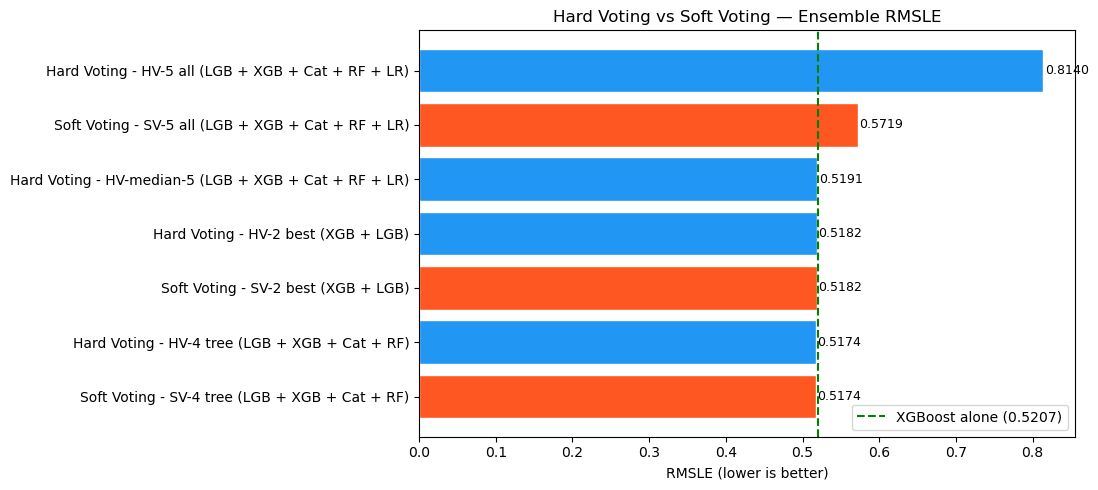

Plot saved to outputs/ensemble_comparison.png


In [13]:
plot_df = comparison[comparison['Type'] == 'Ensemble'].copy()
single_rows = comparison[comparison['Type'] == 'Single'].copy()
best_single_idx = single_rows['Overall RMSLE'].idxmin()
single_best = single_rows.loc[best_single_idx, 'Overall RMSLE']
single_best_name = single_rows.loc[best_single_idx, 'Model']

fig_height = max(5, 0.45 * len(plot_df))
fig, ax = plt.subplots(figsize=(11, fig_height))
colors = ['#2196F3' if 'Hard Voting' in m else '#FF5722' for m in plot_df['Model']]
bars = ax.barh(plot_df['Model'], plot_df['Overall RMSLE'], color=colors, edgecolor='white')
ax.axvline(single_best, color='green', linestyle='--', linewidth=1.5, label=f'{single_best_name} alone ({single_best:.4f})')
ax.set_xlabel('RMSLE (lower is better)')
ax.set_title('Hard Voting vs Soft Voting — Ensemble RMSLE')
ax.legend()

for bar, v in zip(bars, plot_df['Overall RMSLE']):
    ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/ensemble_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to outputs/ensemble_comparison.png')

---
## 12. Save Best Ensemble Predictions

In [ ]:
# Identify best ensemble strategy
ensemble_rmsles = {}
for name, result in hard_results.items():
    ensemble_rmsles[f'Hard Voting - {name}'] = (result['rmsle'], result['pred'])
for name, result in soft_results.items():
    ensemble_rmsles[f'Soft Voting - {name}'] = (result['rmsle'], result['pred'])

best_name = min(ensemble_rmsles, key=lambda k: ensemble_rmsles[k][0])
best_rmsle, best_pred = ensemble_rmsles[best_name]
best_single_spec = min(model_specs, key=lambda s: s['rmsle'])
best_single_name = best_single_spec['name']
best_single_rmsle = best_single_spec['rmsle']

print(f'Best ensemble: {best_name}  (RMSLE = {best_rmsle:.4f})')
print(f'Improvement over best single model ({best_single_name} {best_single_rmsle:.4f}): '
      f'{(best_single_rmsle - best_rmsle):.4f} ({(best_single_rmsle - best_rmsle)/best_single_rmsle*100:.2f}%)')

out = test[['building_id', 'meter', 'timestamp', 'meter_reading']].copy()
out['ensemble_pred'] = best_pred
out['strategy'] = best_name
out.to_csv('../outputs/ensemble_val_predictions.csv', index=False)
print(f'Saved ensemble_val_predictions.csv  ({len(out):,} rows)')

Best ensemble: Soft Voting - SV-4 tree (LGB + XGB + Cat + RF)  (RMSLE = 0.5174)
Improvement over best single model (XGBoost 0.5207): 0.0033 (0.63%)
Saved ensemble_val_predictions.csv  (2,614,072 rows)


---
## Summary

### Hard Voting vs Soft Voting — Key Takeaways

| | Hard Voting | Soft Voting |
|---|---|---|
| **Weights** | Equal (1/N) | Performance-based (1/RMSLE²) |
| **Effect of weak model** | Drags ensemble toward weak model | Weak model auto-down-weighted |
| **Best when** | All models perform similarly | Models have different quality levels |
| **Our case** | HV-4-tree / HV-5-all show the equal-vote effect across all project models | SV-5-all includes every model while down-weighting weak models automatically |

The notebook now includes all five project models: LightGBM, XGBoost, CatBoost, Random Forest, and Linear Regression. XGBoost and CatBoost are evaluated as individual models and are included in the hard-voting, soft-voting, per-meter, comparison, plot, and saved best-ensemble sections.

---

## Sprint 4 — Evaluation & Report